# Red neuronal artificial para reconocer el tipo de un pokemon

En esta tarea ustedes deben diseñar, entrenar y evaluar un modelo de red neuronal con arquitectura convolucional para resolver el problema de reconocer el tipo de un pokemon en base a una imagen del mismo y a sus atributos. El principal desafio es el desbalance y poca cantidad de ejemplos en el dataset. 

A continuación se instancia el dataset y se itera para presentar algunos ejemplos:

Matplotlib is building the font cache; this may take a moment.


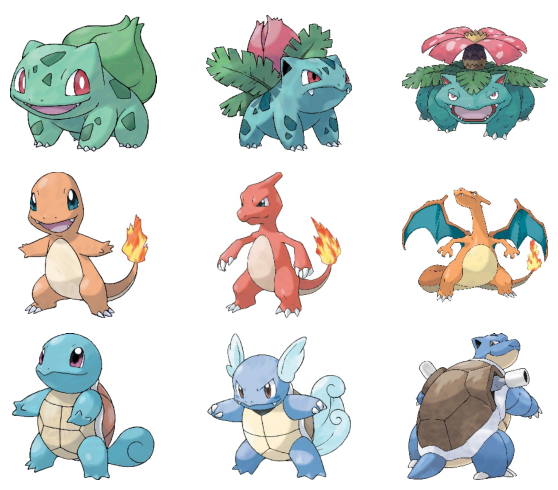

In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
from pokemon_utils import PokemonImages

dataset = PokemonImages('data/')

fig, ax = plt.subplots(3, 3, figsize=(7, 5), tight_layout=True)
for ax_, (image, label, name, attributes) in zip(ax.ravel(), dataset):
    ax_.imshow(image.permute(-2, -1, 0))
    ax_.axis('off');

Cada ejemplo tiene su imagen, su etiqueta, su nombre y sus atributos:

In [5]:
image, label, name, attributes = dataset[0]
type(image), image.shape, label, name, attributes

(torch.Tensor,
 torch.Size([3, 256, 256]),
 np.int64(9),
 'Bulbasaur',
 tensor([ 0.7000,  6.9000, 45.0000, 49.0000, 49.0000, 45.0000]))

Se puede obtener el nombre de la clase con:

In [6]:
dataset.categories[label]

'Grass'

Y los atributos disponibles son:

In [7]:
dataset.attribute_names

['Height', 'Weight', 'HP', 'Attack', 'Defense', 'Speed']

La cantidad de ejemplos por clase es:

In [71]:
from collections import Counter
import pandas as pd
x = Counter(dataset.labels)
for key in sorted(x):
    print(f"{dataset.categories[key]}: {x[key]}")

Bug: 52
Dark: 20
Dragon: 13
Electric: 32
Fairy: 8
Fighting: 20
Fire: 34
Ghost: 18
Grass: 58
Ground: 26
Ice: 19
Normal: 80
Poison: 26
Psychic: 44
Rock: 32
Steel: 17
Water: 96


En lo que sigue utilice los siguientes conjuntos de entrenamiento (train) y prueba (test). 

In [72]:
import numpy as np
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(np.arange(len(dataset)),test_size=0.15, random_state=1234, 
                                       shuffle=True, stratify=dataset.labels)

train_dataset = Subset(dataset, train_idx)
test_dataset = Subset(dataset, test_idx)

# Definición del modelo

Se decidió utilizar una Red Neuronal Convolucional (CNN) inspirada en la arquitectura LeNet-5. Debido a su simplicidad y efectividad para tareas de clasificación de imágenes. Aunque originalmente fue desarrollada para el reconocimiento de dígitos manuscritos, sus principios pueden aplicarse a cualquier problema de clasificación visual. Además, el conjunto de datos utilizado contiene aproximadamente 721 imágenes, por lo que una arquitectura excesivamente profunda podría aumentar el riesgo de sobreajuste. Por esta razón, se seleccionó una arquitectura relativamente simple, capaz de aprender características visuales relevantes sin requerir una gran cantidad de datos para su entrenamiento.

Durante el análisis del conjunto de datos se observó que existen 17 clases distintas correspondientes a los diferentes tipos de Pokémon presentes en el dataset. Esta información es importante para definir la arquitectura de la red, ya que determina el número de neuronas necesarias en la capa de salida.

## Arquitectura propuesta

```text
Entrada (Imagen RGB 256×256)
        ↓
      Conv1
        ↓
      ReLU
        ↓
   MaxPooling
        ↓
      Conv2
        ↓
      ReLU
        ↓
   MaxPooling
        ↓
      Conv3
        ↓
      ReLU
        ↓
   MaxPooling
        ↓
     Flatten
        ↓
 Fully Connected
        ↓
      Dropout
        ↓
  Capa de Salida
```

## Descripción de cada componente

- **Conv1:** Corresponde a la primera capa convolucional. Su objetivo es detectar características visuales básicas presentes en la imagen, tales como bordes, contrastes, cambios de color y texturas simples.

- **ReLU:** Corresponde a la función de activación ReLU (Rectified Linear Unit). Su función es introducir no linealidad en el modelo, permitiendo aprender relaciones más complejas entre las características visuales y las clases objetivo.

- **MaxPooling:** Esta capa reduce el tamaño de las representaciones internas generadas por la convolución, conservando la información más relevante. Esto disminuye el costo computacional y ayuda a reducir el riesgo de sobreajuste.

- **Conv2:** Corresponde a la segunda capa convolucional. Esta capa combina las características aprendidas por la primera capa para identificar patrones de mayor complejidad, como formas, contornos y partes características de los Pokémon.

- **Conv3:** Corresponde a la tercera capa convolucional. Su objetivo es construir representaciones más abstractas de la imagen, identificando estructuras visuales complejas a partir de la combinación de las características aprendidas en las capas anteriores.

- **Flatten:** Transforma los mapas de activación obtenidos por las capas convolucionales en un vector unidimensional, permitiendo conectar la etapa de extracción de características con las capas de clasificación.

- **Fully Connected:** Corresponde a una capa completamente conectada encargada de combinar todas las características extraídas previamente y generar la predicción final de la clase.

- **Dropout:** Corresponde a una técnica de regularización utilizada para reducir el riesgo de sobreajuste. Durante el entrenamiento desactiva aleatoriamente una fracción de las neuronas, obligando a la red a aprender representaciones más robustas y mejorando su capacidad de generalización.

- **Capa de Salida:** Entrega la clasificación final del tipo de Pokémon. Se utilizaron 17 neuronas de salida, una por cada clase presente en el conjunto de datos, permitiendo que la red asigne una probabilidad a cada tipo y seleccione la más probable como predicción final.

In [ ]:
#dimencionalidad de la imagen
# numero de clases
print(image.shape)
print(attributes.shape)

labels = [dataset[i][1] for i in range(len(dataset))]
print("Número de clases:", len(set(labels)))

torch.Size([3, 256, 256])
torch.Size([6])
Número de clases: 17


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PokemonCNN(nn.Module):

    def __init__(self):

        # Inicializa la clase padre de PyTorch
        super().__init__()

        # =====================================================
        # CAPAS CONVOLUCIONALES
        # =====================================================

        # Primera capa convolucional
        # Recibe imágenes RGB (3 canales)
        # Genera 16 mapas de características
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        # Segunda capa convolucional
        # Recibe los 16 mapas generados anteriormente
        # y produce 32 mapas de características
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Tercera capa convolucional
        # Permite aprender patrones visuales más complejos
        self.conv3 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # =====================================================
        # MAX POOLING
        # =====================================================

        # Reduce a la mitad las dimensiones espaciales
        # Ejemplo:
        # 256x256 -> 128x128
        # 128x128 -> 64x64
        # 64x64 -> 32x32
        self.pool = nn.MaxPool2d(kernel_size=2)

        # =====================================================
        # GLOBAL AVERAGE POOLING
        # =====================================================

        # Convierte cada mapa de características
        # en un único valor promedio.
        #
        # Ejemplo:
        # 64 x 32 x 32
        # pasa a
        # 64 x 1 x 1
        #
        # Esto reduce drásticamente el número de parámetros
        # y ayuda a evitar overfitting.
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # =====================================================
        # CAPAS FULLY CONNECTED
        # =====================================================

        # Después del Global Average Pooling quedan:
        #
        # 64 características visuales
        #
        # Además se agregan:
        #
        # 6 atributos numéricos del Pokémon
        #
        # Total:
        # 64 + 6 = 70 entradas
        self.fc1 = nn.Linear(
            64 + 6,
            128
        )

        # Dropout:
        # durante el entrenamiento desactiva
        # aleatoriamente un 30% de las neuronas
        # para reducir el sobreajuste.
        self.dropout = nn.Dropout(0.3)

        # Capa de salida
        #
        # Existen 17 clases en el dataset,
        # por lo tanto se utilizan 17 neuronas.
        self.fc2 = nn.Linear(
            128,
            18
        )

    def forward(self, image, attributes):

        # =====================================================
        # BLOQUE CONVOLUCIONAL 1
        # =====================================================

        # Conv1 -> ReLU -> MaxPooling
        x = self.pool(
            F.relu(
                self.conv1(image)
            )
        )

        # =====================================================
        # BLOQUE CONVOLUCIONAL 2
        # =====================================================

        # Conv2 -> ReLU -> MaxPooling
        x = self.pool(
            F.relu(
                self.conv2(x)
            )
        )

        # =====================================================
        # BLOQUE CONVOLUCIONAL 3
        # =====================================================

        # Conv3 -> ReLU -> MaxPooling
        x = self.pool(
            F.relu(
                self.conv3(x)
            )
        )

        # =====================================================
        # GLOBAL AVERAGE POOLING
        # =====================================================

        x = self.global_pool(x)

        # =====================================================
        # FLATTEN
        # =====================================================

        # Convierte el tensor en un vector
        # para poder ingresarlo a las capas densas.
        x = torch.flatten(
            x,
            start_dim=1
        )

        # =====================================================
        # CONCATENACIÓN DE ATRIBUTOS
        # =====================================================

        # Combina las características visuales
        # obtenidas por la CNN con los atributos
        # numéricos del Pokémon.
        x = torch.cat(
            [x, attributes.float()],
            dim=1
        )

        # =====================================================
        # CLASIFICADOR
        # =====================================================

        # Primera capa densa
        x = F.relu(
            self.fc1(x)
        )

        # Regularización
        x = self.dropout(x)

        # Capa de salida
        x = self.fc2(x)

        return x

Se verifica que el modelo recibe correctamente la imagen y los atributos, y produce una salida con 17 clases:

In [ ]:
model = PokemonCNN()

image, label, name, attributes = dataset[0]

image_b = image.unsqueeze(0)          # agrega dimensión batch
attributes_b = attributes.unsqueeze(0)

output = model(image_b, attributes_b)

print("Forma de la salida:", output.shape)  # Esperado: torch.Size([1, 17])
print(model)
print("Parámetros totales:", sum(p.numel() for p in model.parameters()))

Forma de la salida: torch.Size([1, 18])
PokemonCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=70, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=18, bias=True)
)
Parámetros totales: 34994


### Entrenamiento del modelo

Entrene el modelo y muestre las curvas de aprendizaje. Justifique la elección de hiperparámetros.

# Entrenamiento del modelo

El conjunto de datos fue dividido en tres subconjuntos:

- **70%** para entrenamiento.
- **15%** para validación.
- **15%** para prueba (definido anteriormente mediante `train_test_split`).

La partición de validación permite monitorear el desempeño del modelo durante el entrenamiento y detectar posibles problemas de sobreajuste, mientras que el conjunto de prueba se reserva para la evaluación final.

## Hiperparámetros

Se utilizó la función de pérdida **CrossEntropyLoss** debido a que el problema corresponde a una tarea de clasificación multiclase. Esta función combina internamente un softmax con la entropía cruzada, lo que la hace adecuada para este tipo de problemas.

Como optimizador se seleccionó **Adam** con una tasa de aprendizaje de **0.001**. Adam adapta la tasa de aprendizaje para cada parámetro durante el entrenamiento, lo que permite una convergencia más rápida y estable en comparación con el descenso de gradiente estándar.

Se utilizó un **tamaño de lote de 32** muestras, lo cual proporciona un equilibrio adecuado entre estabilidad del gradiente y eficiencia computacional. Lotes demasiado pequeños producen gradientes ruidosos, mientras que lotes muy grandes pueden dificultar la generalización del modelo.

Se entrenó el modelo durante **50 épocas**, número suficiente para observar la tendencia de las curvas de aprendizaje y detectar sobreajuste sin incurrir en un costo computacional excesivo.

In [84]:
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# =====================================================
# DIVISIÓN DEL CONJUNTO DE DATOS
# =====================================================

# Se utiliza el train_dataset obtenido previamente
# y se extrae una partición de validación del 15%.
# El test_dataset ya fue definido anteriormente.

dataset_size = len(train_dataset)
val_size = int(0.15 * len(dataset))
train_size = dataset_size - val_size

train_set, val_set = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(1234)
)

# =====================================================
# DATA LOADERS
# =====================================================

batch_size = 32

train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f"Muestras de entrenamiento : {len(train_set)}")
print(f"Muestras de validación    : {len(val_set)}")
print(f"Muestras de prueba        : {len(test_dataset)}")

Muestras de entrenamiento : 416
Muestras de validación    : 89
Muestras de prueba        : 90


In [85]:
# =====================================================
# INSTANCIA DEL MODELO, CRITERIO Y OPTIMIZADOR
# =====================================================

model = PokemonCNN()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)
print("Parámetros totales:", sum(p.numel() for p in model.parameters()))

PokemonCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=70, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=18, bias=True)
)
Parámetros totales: 34994


In [86]:
for i in range(len(dataset)):
    label = dataset[i][1]

    if label == 17:
        print(i)
        break

6


In [87]:
# =====================================================
# BUCLE DE ENTRENAMIENTO
# =====================================================

num_epochs = 50

train_losses = []
val_losses   = []

for epoch in range(num_epochs):

    # ------ Fase de entrenamiento ------
    model.train()

    running_loss = 0.0

    for images, labels, names, attributes in train_loader:

        optimizer.zero_grad()

        outputs = model(images, attributes)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ------ Fase de validación ------
    model.eval()

    running_val = 0.0

    with torch.no_grad():

        for images, labels, names, attributes in val_loader:

            outputs = model(images, attributes)

            loss = criterion(outputs, labels)

            running_val += loss.item()

    val_loss = running_val / len(val_loader)
    val_losses.append(val_loss)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch+1:>3}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f}  "
            f"Val Loss: {val_loss:.4f}"
        )

Epoch [  5/50] Train Loss: 2.7395  Val Loss: 3.2122
Epoch [ 10/50] Train Loss: 2.4383  Val Loss: 2.9388
Epoch [ 15/50] Train Loss: 2.3625  Val Loss: 2.9050
Epoch [ 20/50] Train Loss: 2.2672  Val Loss: 2.8785
Epoch [ 25/50] Train Loss: 2.2096  Val Loss: 2.8913
Epoch [ 30/50] Train Loss: 2.1770  Val Loss: 2.9400
Epoch [ 35/50] Train Loss: 2.1514  Val Loss: 2.8397
Epoch [ 40/50] Train Loss: 2.0889  Val Loss: 2.9483
Epoch [ 45/50] Train Loss: 2.0979  Val Loss: 2.8856
Epoch [ 50/50] Train Loss: 2.0512  Val Loss: 2.9130


## Curvas de aprendizaje

Las curvas de aprendizaje permiten visualizar la evolución de la pérdida en entrenamiento y validación a lo largo de las épocas. Si ambas curvas disminuyen de forma similar, el modelo está generalizando correctamente. Si la pérdida de validación aumenta mientras la de entrenamiento sigue bajando, es señal de sobreajuste.

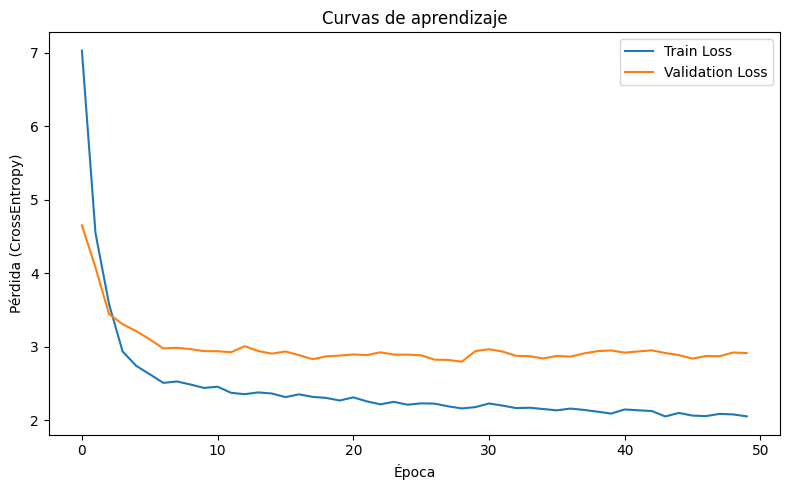

In [88]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Validation Loss")

plt.xlabel("Época")
plt.ylabel("Pérdida (CrossEntropy)")
plt.title("Curvas de aprendizaje")
plt.legend()
plt.tight_layout()
plt.show()

### Evaluación del modelo

Evalúe el modelo en el conjunto de prueba usando matriz de confusión y reporte de clasificación. Discuta los resultados.

### Análisis de errores

Analice algunos ejemplos mal clasificados y comente lo que observa.

### Aumentación de datos

Implemente un esquema de aumentación aleatoria de datos y compare los resultados con y sin aumentación.